In [1]:
import numpy as np 
import pandas as pd
import pickle
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path 

In [2]:
import yaml 


In [3]:
!ls binaural_eval

test_voice_cue_only_word_task_mixed_cue_large_architecture_0dB
test_voice_cue_only_word_task_mixed_cue_large_architecture_v03_0dB
word_task_mixed_cue_large_architecture_0dB
word_task_voice_loc_cue
word_task_voice_loc_cue_-9dB
word_task_voice_loc_cue_0dB
word_task_voice_loc_cue_9dB


In [4]:
output_paths = Path("binaural_eval/test_voice_cue_only_word_task_mixed_cue_large_architecture_v03_0dB").glob("*.pkl")


In [5]:
results_dfs = []
for path in output_paths:
    res_dict = pickle.load(open(path, 'rb'))
    for cond, meta in res_dict.items():
        # reformat dict
        record = {}
        record['sex_pairing'] = cond
        record['target_azim'] = meta['target_loc'][0]
        record['target_elev'] = meta['target_loc'][1]
        record['distractor_azim'] = meta['distract_loc'][0]
        record['distractor_elev'] = meta['distract_loc'][1]
        record['word_acc'] = meta['results'][0]
        record['word_error'] = meta['results'][1]
        record['confusions'] = meta['confusions'][0]
        record['confusion_error'] = meta['confusions'][1]

        df = pd.DataFrame.from_records([record])
        results_dfs.append(df)
results = pd.concat(results_dfs)

In [6]:
remap_azim = lambda azim: 360 - azim if azim > 90 else 0 - azim 

results['target_azim'] = results['target_azim'].apply(remap_azim)
results['distractor_azim'] = results['distractor_azim'].apply(remap_azim)

In [7]:
results

,sex_pairing,target_azim,target_elev,distractor_azim,distractor_elev,word_acc,word_error,confusions,confusion_error
0,m_m,0,0,0,0,0.155894,0.012923,0.081115,0.009726
0,m_f,0,0,0,0,0.163498,0.013174,0.059569,0.008432
0,f_m,0,0,0,0,0.154626,0.012880,0.082383,0.009795
0,f_f,0,0,0,0,0.138150,0.012292,0.091255,0.010259
0,m_m,0,0,-10,0,0.145754,0.012570,0.086185,0.009997
...,...,...,...,...,...,...,...,...,...
0,f_f,-90,0,-80,0,0.124208,0.011749,0.083650,0.009863
0,m_m,-90,0,-90,0,0.158428,0.013008,0.083650,0.009863
0,m_f,-90,0,-90,0,0.167300,0.013296,0.064639,0.008759
0,f_m,-90,0,-90,0,0.163498,0.013174,0.074778,0.009370


In [8]:
sex_map = {'m_m':'same', "m_f":'diff', 'f_m':'diff', 'f_f':'same'}
results['sex_cond'] = results.sex_pairing.map(sex_map)

In [9]:
results[results.sex_cond == 'same'].sex_pairing.unique()

array(['m_m', 'f_f'], dtype=object)

In [10]:
results[results.sex_cond == 'diff'].sex_pairing.unique()

array(['m_f', 'f_m'], dtype=object)

In [11]:
results.groupby(["target_azim", "distractor_azim"]).mean()

target_elev  distractor_elev  word_acc  \
target_azim distractor_azim                                           
-90         -90                      0.0              0.0  0.154626   
            -80                      0.0              0.0  0.161914   
            -70                      0.0              0.0  0.154943   
            -60                      0.0              0.0  0.146071   
            -50                      0.0              0.0  0.153359   
...                                  ...              ...       ...   
 90          50                      0.0              0.0  0.160646   
             60                      0.0              0.0  0.173321   
             70                      0.0              0.0  0.167934   
             80                      0.0              0.0  0.172687   
             90                      0.0              0.0  0.161914   

                             word_error  confusions  confusion_error  
target_azim distractor_azim                                           
-90         -90                0.012858    0.079848         0.009626  
            -80                0.013070    0.068758         0.008878  
            -70                0.012866    0.069392         0.008979  
            -60                0.012562    0.083333         0.009749  
            -50                0.012820    0.078580         0.009527  
...                                 ...         ...              ...  
 90          50                0.013046    0.069708         0.008993  
             60                0.013458    0.067807         0.008925  
             70                0.013287    0.066857         0.008843  
             80                0.013430    0.061470         0.008507  
             90                0.013094    0.075095         0.009327  

[353 rows x 6 columns]

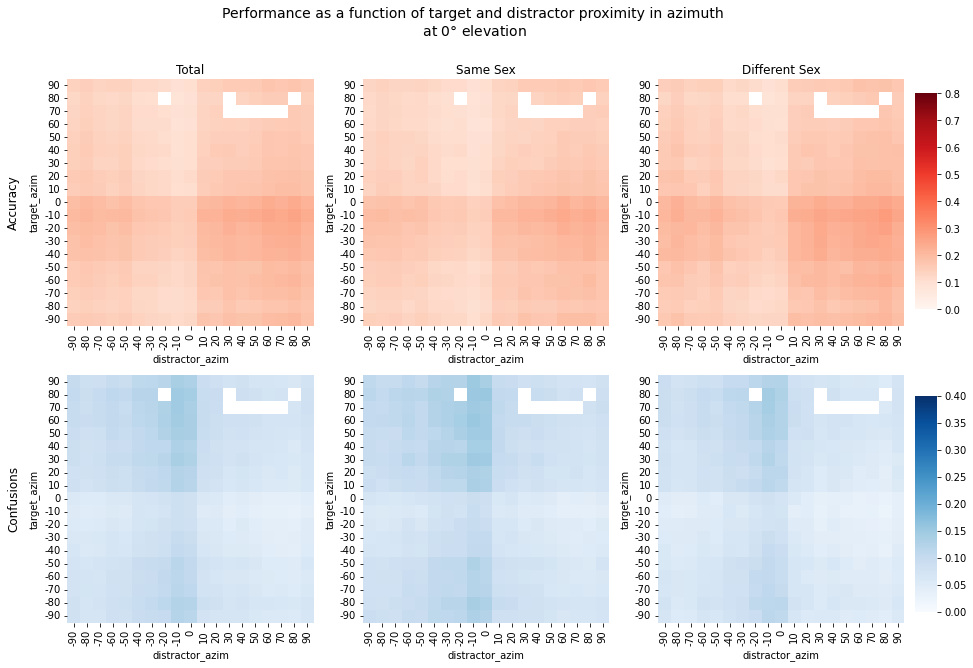

In [12]:
# plot all plots so far onto one figure
cols = ['Total', 'Same Sex', 'Different Sex']
rows = ['Accuracy', 'Confusions']

fig, axs = plt.subplots(2, 3, figsize=(15, 10), sharex=False, sharey=False)

cbar_ax_1 = fig.add_axes([.91, .56, .02, .3])
cbar_ax_2 = fig.add_axes([.91, .14, .02, .3])

total_acc = results.groupby(["target_azim", "distractor_azim"]).mean()['word_acc']
sns.heatmap(total_acc.unstack(), vmin=0, vmax=0.8, cmap='Reds', cbar=True, cbar_ax=cbar_ax_1, ax=axs[0, 0])
total_con = results.groupby(['target_azim', 'distractor_azim']).mean()['confusions']
sns.heatmap(total_con.unstack(), vmin=0, vmax=0.4, cmap='Blues', cbar=True, cbar_ax=cbar_ax_2, ax=axs[1, 0])

same_sex = results[results.sex_cond == 'same']
same_sex_acc = same_sex.groupby(['target_azim', 'distractor_azim'])['word_acc'].mean()
sns.heatmap(same_sex_acc.unstack(), vmin=0, vmax= 0.8, cmap='Reds', cbar=False, cbar_ax=None, ax=axs[0, 1])
same_sex_con = same_sex.groupby(['target_azim', 'distractor_azim'])['confusions'].mean()
sns.heatmap(same_sex_con.unstack(), vmin=0, vmax=0.4, cmap='Blues', cbar=False, cbar_ax=None, ax=axs[1, 1])

diff_sex = results[results.sex_cond == 'diff']
diff_sex_acc = diff_sex.groupby(['target_azim', 'distractor_azim'])['word_acc'].mean()
sns.heatmap(diff_sex_acc.unstack(), vmin=0, vmax=0.8, cmap='Reds', cbar=False, cbar_ax=None, ax=axs[0, 2])
diff_sex_con = diff_sex.groupby(['target_azim', 'distractor_azim'])['confusions'].mean()
sns.heatmap(diff_sex_con.unstack(), vmin=0, vmax=0.4, cmap='Blues', cbar=False, cbar_ax=None, ax=axs[1, 2])

for ax, col in zip(axs[0], cols):
    ax.annotate(col, xy=(0.5, 1), xytext=(0, 5), size='large', ha='center', va='baseline', xycoords='axes fraction', textcoords='offset points',)
for ax, row in zip(axs[:, 0], rows):
    ax.annotate(row, xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - 5, 0), xycoords=ax.yaxis.label, textcoords='offset points', size='large', ha='right', va='center', rotation=90)

# fig.tight_layout(rect=[0,0,.9,1])
plt.suptitle('Performance as a function of target and distractor proximity in azimuth\n at $0\degree$ elevation', fontsize=14, y=0.98);

for ax in axs.flatten():
    ax.invert_yaxis()


In [13]:
diff_sex = results[results.sex_cond == 'diff']
diff_sex

,sex_pairing,target_azim,target_elev,distractor_azim,distractor_elev,word_acc,word_error,confusions,confusion_error,sex_cond
0,m_f,0,0,0,0,0.163498,0.013174,0.059569,0.008432,diff
0,f_m,0,0,0,0,0.154626,0.012880,0.082383,0.009795,diff
0,m_f,0,0,-10,0,0.173638,0.013494,0.064639,0.008759,diff
0,f_m,0,0,-10,0,0.150824,0.012749,0.092522,0.010322,diff
0,m_f,0,0,-20,0,0.182510,0.013760,0.055767,0.008175,diff
...,...,...,...,...,...,...,...,...,...,...
0,f_m,-90,0,-70,0,0.150824,0.012749,0.065906,0.008839,diff
0,m_f,-90,0,-80,0,0.185044,0.013834,0.035488,0.006591,diff
0,f_m,-90,0,-80,0,0.178707,0.013648,0.068441,0.008995,diff
0,m_f,-90,0,-90,0,0.167300,0.013296,0.064639,0.008759,diff


In [14]:
np.sqrt(np.mean((diff_sex_acc.values - same_sex_acc.values)**2))

0.022248267492848917

In [15]:
np.sqrt(np.mean((diff_sex_con.values - same_sex_con.values)**2))

0.018825802354302

In [16]:
diff_sex

,sex_pairing,target_azim,target_elev,distractor_azim,distractor_elev,word_acc,word_error,confusions,confusion_error,sex_cond
0,m_f,0,0,0,0,0.163498,0.013174,0.059569,0.008432,diff
0,f_m,0,0,0,0,0.154626,0.012880,0.082383,0.009795,diff
0,m_f,0,0,-10,0,0.173638,0.013494,0.064639,0.008759,diff
0,f_m,0,0,-10,0,0.150824,0.012749,0.092522,0.010322,diff
0,m_f,0,0,-20,0,0.182510,0.013760,0.055767,0.008175,diff
...,...,...,...,...,...,...,...,...,...,...
0,f_m,-90,0,-70,0,0.150824,0.012749,0.065906,0.008839,diff
0,m_f,-90,0,-80,0,0.185044,0.013834,0.035488,0.006591,diff
0,f_m,-90,0,-80,0,0.178707,0.013648,0.068441,0.008995,diff
0,m_f,-90,0,-90,0,0.167300,0.013296,0.064639,0.008759,diff


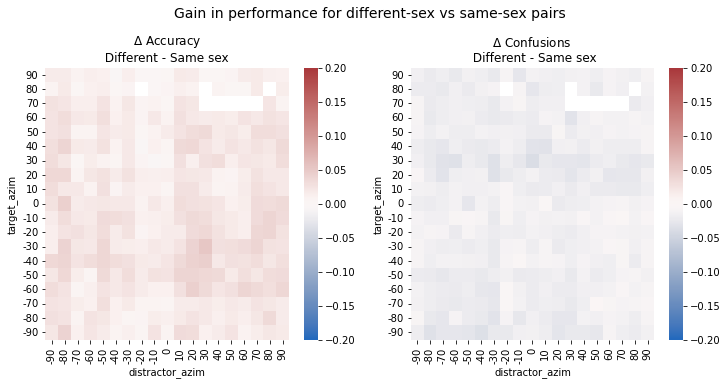

In [17]:
# plot all plots so far onto one figure
# cols = ['Total', 'Same Sex', 'Different Sex']
# rows = ['word_acc', 'Confusions']

fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharex=False, sharey=False)

# cbar_ax_1 = fig.add_axes([.91, .56, .02, .3])
# cbar_ax_2 = fig.add_axes([.91, .14, .02, .3])

diff_sex = results[results.sex_cond == 'diff']
same_sex = results[results.sex_cond == 'same']

diff = diff_sex.groupby(["target_azim", "distractor_azim"])['word_acc'].mean() - same_sex.groupby(["target_azim", "distractor_azim"])['word_acc'].mean()
sns.heatmap(diff.unstack(), vmin=-0.20, vmax=0.20, cmap='vlag', cbar=True, ax=axs[0]) #  cbar_ax=cbar_ax_1,

diff = diff_sex.groupby(["target_azim", "distractor_azim"])['confusions'].mean() - same_sex.groupby(["target_azim", "distractor_azim"])['confusions'].mean()
sns.heatmap(diff.unstack(), vmin=-0.20, vmax=0.20, cmap='vlag', cbar=True,  ax=axs[1]) # cbar_ax=cbar_ax_2,

# for ax, col in zip(axs[0], cols):
axs[0].set_title("$\Delta$ Accuracy \n Different - Same sex ", )#xy=(0.5, 1), xytext=(0, 5), size='large', ha='center', va='baseline', xycoords='axes fraction', textcoords='offset points',)
# for ax, row in zip(axs[1], rows):
axs[1].set_title("$\Delta$ Confusions \n Different - Same sex") # , xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - 5, 0), xycoords=ax.yaxis.label, textcoords='offset points', size='large', ha='right', va='center', rotation=90)

# fig.tight_layout(rect=[0,0,.9,1])
plt.suptitle('Gain in performance for different-sex vs same-sex pairs', fontsize=14, y=1.05);

for ax in axs.flatten():
    ax.invert_yaxis()